In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import json


from scipy import sparse
import ast
import random
from tqdm import tqdm

In [7]:
raw_data_dir = "raw_M3D_Seg"
sub_dataset = os.listdir(raw_data_dir)

for dataset in sub_dataset:
    dataset_dir = os.path.join(raw_data_dir, dataset)
    print(dataset_dir)
    print(os.listdir(dataset_dir))

raw_M3D_Seg\0000
['0000.json', '1', '10', '14', '16', '18', '19', '2', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '5', '6', '8']
raw_M3D_Seg\0001
['0001.json', 'case_01', 'case_02', 'case_03', 'case_04', 'case_05', 'case_06', 'case_07', 'case_08', 'case_09', 'case_10', 'case_11', 'case_12', 'case_13', 'case_14', 'case_15', 'case_16', 'case_17', 'case_18', 'case_19', 'case_20', 'case_21', 'case_22', 'case_23', 'case_24', 'case_25', 'case_26', 'case_27', 'case_28', 'case_29', 'case_30', 'case_31', 'case_32', 'case_33', 'case_34', 'case_35', 'case_36', 'case_37', 'case_38', 'case_39', 'case_40', 'case_41', 'case_42']
raw_M3D_Seg\0002
['0002.json', 'amos_0001', 'amos_0004', 'amos_0005', 'amos_0006', 'amos_0007', 'amos_0009', 'amos_0010', 'amos_0011', 'amos_0014', 'amos_0015', 'amos_0016', 'amos_0017', 'amos_0019', 'amos_0021', 'amos_0023', 'amos_0024', 'amos_0025', 'amos_0027', 'amos_0030', 'amos_0033', 'amos_0035', 'amos_0036', 'amos_0038', 'amos_0042', 'amos_0043', 'amos

In [39]:



json_file_path = "0001/0001.json"


with open(json_file_path) as file:
    data = json.load(file)

train_data = data['train']
test_data = data['test']

train_data



[{'image': '0001/case_01/image.npy',
  'label': '0001/case_01/mask_(30, 1024, 1024, 202).npz'},
 {'image': '0001/case_42/image.npy',
  'label': '0001/case_42/mask_(30, 1024, 1024, 205).npz'},
 {'image': '0001/case_02/image.npy',
  'label': '0001/case_02/mask_(30, 1024, 1024, 204).npz'},
 {'image': '0001/case_27/image.npy',
  'label': '0001/case_27/mask_(30, 1024, 1024, 200).npz'},
 {'image': '0001/case_29/image.npy',
  'label': '0001/case_29/mask_(30, 1024, 1024, 233).npz'},
 {'image': '0001/case_16/image.npy',
  'label': '0001/case_16/mask_(30, 1024, 1024, 132).npz'},
 {'image': '0001/case_10/image.npy',
  'label': '0001/case_10/mask_(30, 1024, 1024, 143).npz'},
 {'image': '0001/case_20/image.npy',
  'label': '0001/case_20/mask_(30, 1024, 1024, 134).npz'},
 {'image': '0001/case_21/image.npy',
  'label': '0001/case_21/mask_(30, 1024, 1024, 215).npz'},
 {'image': '0001/case_30/image.npy',
  'label': '0001/case_30/mask_(30, 1024, 1024, 214).npz'},
 {'image': '0001/case_08/image.npy',
  '

In [42]:
# try for case 1 (dataset 0001)
img_dir = '0001/case_01/image.npy'
mask_dir = '0001/case_01/mask_(30, 1024, 1024, 202).npz'

img = np.load(img_dir)
mask = np.load(mask_dir)

In [47]:

#ct_file_path = os.path.join(uniseg_path, dataset_dict['train'][0]['image'])
#gt_file_path = os.path.join(uniseg_path, dataset_dict['train'][0]['label'])

img_array = np.load(img_dir)[0]
print('img_array.shape ', img_array.shape)

allmatrix_sp= sparse.load_npz(mask_dir)
gt_shape = ast.literal_eval(mask_dir.split('.')[-2].split('_')[-1])
gt_array=allmatrix_sp.toarray().reshape(gt_shape)
print('gt_array.shape ', gt_array.shape)

img_array.shape  (1024, 1024, 202)
gt_array.shape  (30, 1024, 1024, 202)


In [50]:
merged_gt_array = np.any(gt_array, axis=0)
merged_gt_array.shape

(1024, 1024, 202)

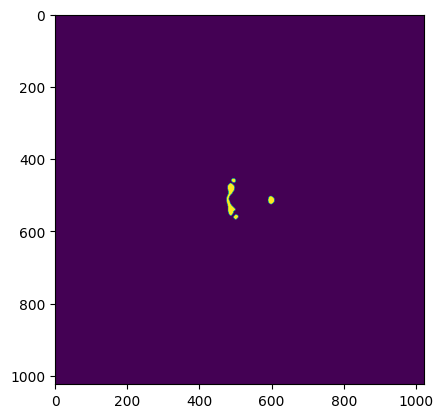

In [61]:
plt.imshow(merged_gt_array[:,:,50])

In [9]:
def crop_patient_image(case_folder, min_size = 100, padding = 0):
    downsample = False
    files = os.listdir(case_folder)
    img_file = [f for f in files if 'image' in f][0]
    mask_file = [f for f in files if 'mask' in f][0]
    img_dir = os.path.join(case_folder, img_file)
    mask_dir = os.path.join(case_folder, mask_file)

    # load image file
    img = np.load(img_dir)
    if img.shape[1] >= 500:
        downsample = True
        img = img[:, ::2, ::2, :]  # NOTE: downsampled the slice resolution by 2 !!

    #print(np.array(img.shape)[1:])
    original_img_shape = np.array(img.shape)[1:]
    if np.any(original_img_shape < min_size):
        #print('Image is smaller than minimum size.', img.shape, min_size)
        return None

    # load segmentation mask file
    allmatrix_sp= sparse.load_npz(mask_dir)
    gt_shape = ast.literal_eval(mask_dir.split('.')[-2].split('_')[-1])
    gt_array=allmatrix_sp.toarray().reshape(gt_shape)
    #print('gt_array.shape ', gt_array.shape)
    if downsample:
        gt_array = gt_array[:,::2,::2,:]

    # find bounding box of all segmentations
    merged_gt_array = np.any(gt_array, axis=0)  # collapse the one-hot encoded segmentation masks into a single mask
    true_indices = np.argwhere(merged_gt_array)
    #true_indices = true_indices[:, ::2, ::2, :]
    
    # find the min and max coordinates of the bounding box, add padding
    min_coords = np.min(true_indices, axis=0) - padding
    max_coords = np.max(true_indices, axis=0) + padding

    #print(min_coords, max_coords, original_img_shape)

    # make sure max_ and min_coords is within the image
    min_coords = np.where(min_coords < 0, 0, min_coords)
    max_coords = np.where(max_coords > original_img_shape, original_img_shape, max_coords)

    BB_center = (min_coords + max_coords) // 2
    BB_size = max_coords - min_coords

    #print("BB_size", BB_size)


    # check BB is large enough
    if np.any(BB_size < min_size):
        BB_size = np.where(BB_size < min_size, min_size, BB_size)
    
    BB_min_coords = BB_center - BB_size // 2
    BB_max_coords = BB_center + BB_size // 2

    #print(BB_min_coords, BB_max_coords, original_img_shape)

    # check the BB is still within the image
    # move the box if the coordinates are out of the image (any min BB coord less than 0)
    excedes_min = np.where(BB_min_coords < 0, abs(BB_min_coords), 0)

    BB_min_coords += excedes_min
    BB_max_coords += excedes_min

    #print(BB_min_coords, BB_max_coords, original_img_shape)
    # do the same now if the max coord is bigger than the image in any direction
    excedes_max = np.where(BB_max_coords > original_img_shape, BB_max_coords - original_img_shape, 0)
    #print(excedes_max)
    BB_min_coords -= excedes_max
    BB_max_coords -= excedes_max

    #print(BB_min_coords, BB_max_coords, original_img_shape)
    #print()
    # if any of the new coordinates are less than 0, the BB is not large enough
    if np.any(BB_min_coords < 0):
        return None


    cropped_img = img[:, BB_min_coords[0]:BB_max_coords[0], BB_min_coords[1]:BB_max_coords[1], BB_min_coords[2]:BB_max_coords[2]]

    return cropped_img


In [31]:
raw_data_dir = 'raw_M3D_Seg'
#raw_data_dir = 'Z:/raw_M3D_Seg'
cropped_data_dir = 'cropped_M3D_Seg_3'

train_folder = 'train'
test_folder = 'test'
test_set_size = 0.1



os.makedirs(cropped_data_dir, exist_ok=True)
os.makedirs(os.path.join(cropped_data_dir, train_folder), exist_ok=True)
os.makedirs(os.path.join(cropped_data_dir, test_folder), exist_ok=True)

# done 
# todo: 13, 14, 0, 2, 1, 5, 7, 8, 9, 10
# 15, 16, 17, 18, 19, 21, 22, 23



# DONE: 0,1,2,3,4,5,6,7,8,9,10,11  14,15,  19, 20, 23 24 

# REDOWNLOAD:  

#datasets_to_process = ["0024"]

for subset in os.listdir(raw_data_dir):  # NOTE: does all data subsets
#for subset in datasets_to_process:
    print(subset)
    subset_dir = os.path.join(raw_data_dir, subset)

    json_file = os.path.join(subset_dir, subset + '.json')
    with open(json_file) as file:
        data = json.load(file)

    train_data = data['train']
    test_data = data['test']

    case_folders = [folder for folder in os.listdir(subset_dir) if os.path.isdir(os.path.join(subset_dir, folder))]
    #print(case_folders)
    total_cases = 0
    too_small = 0
    
    for case_idx, case in enumerate(tqdm(case_folders)):
        case_folder = os.path.join(subset_dir, case)
        cropped_img = crop_patient_image(case_folder)

        if cropped_img is None:
            too_small += 1
            continue
            
        total_cases += 1

        # decide if patient is in train or test set
        if random.random() <= test_set_size:
            split_set = test_folder
        else:
            split_set = train_folder

        # NOTE: temporarily save all np files in the same folder
        split_set = 'train'
        #print(cropped_img.shape)

        #plt.imshow(cropped_img[0, :, :, 50]) 
        #plt.show()
        save_dir = os.path.join(cropped_data_dir, split_set, f"{subset}_{case_idx}.npy")  # NOTE: Commented out the saving for now

        np.save(save_dir, cropped_img)

    print(subset, total_cases, too_small)

        

        # print(case_folder, cropped_img.shape)
        # cropped_img_dir = os.path.join(cropped_data_dir, subset, case)
        # np.save(cropped_img_dir, cropped_img)

0020


100%|██████████| 131/131 [02:02<00:00,  1.07it/s]


0020 122 9
0023


100%|██████████| 41/41 [00:05<00:00,  7.43it/s]

0023 13 28


In [36]:
def get_array_mean_std(ct_voxel_ndarray):
    #ct_voxel_ndarray = ct_array.copy()
    #ct_voxel_ndarray = ct_voxel_ndarray.flatten()
    # for all data

    #thred = np.mean(ct_voxel_ndarray)
    #voxel_filtered = ct_voxel_ndarray[(ct_voxel_ndarray > thred)]
    voxel_filtered = ct_voxel_ndarray
    #print(voxel_filtered.shape)
    # for foreground data
    upper_bound = np.percentile(voxel_filtered, 99.95)
    lower_bound = np.percentile(voxel_filtered, 00.05)
    mean = np.mean(voxel_filtered)
    std = np.std(voxel_filtered)

    return mean, std, upper_bound, lower_bound

def normalize(ct_narray, mean, std, upper_bound, lower_bound):
   
    ### transform ###
    ct_narray = np.clip(ct_narray, lower_bound, upper_bound)
    ct_narray = (ct_narray - lower_bound) / (upper_bound - lower_bound)
    #ct_narray = (ct_narray - mean) / max(mean, 1e-8)
    return ct_narray

In [40]:
import numpy as np
import os

saved_dir = r"C:\Users\danie\Desktop\FSE 23-34\Master's Project\DL_NTCP_Multitox\datasets\cropped_M3D_Seg_2\original"
files = os.listdir(saved_dir)

new_dir = r"C:\Users\danie\Desktop\FSE 23-34\Master's Project\DL_NTCP_Multitox\datasets\cropped_M3D_Seg_2\blocks"
os.makedirs(new_dir, exist_ok=True)
block_size = 100

for filename in tqdm(files):
#for filename in ["0002_116.npy"]:
    arr_dir = os.path.join(saved_dir, filename)
    arr = np.load(arr_dir)
    #print(arr.shape)
    _, height, width, depth = arr.shape

    # normalise the image here as well !
    mean, std, upper_bound, lower_bound = get_array_mean_std(arr)
    arr = normalize(arr, mean, std, upper_bound, lower_bound)
    #print(arr.max(), arr.min())
    
    #print(npar.shape)

    blocks_in_height = height // block_size
    blocks_in_width = width // block_size
    blocks_in_depth = depth // block_size

    if not any([blocks_in_height > 1, blocks_in_width > 1, blocks_in_depth > 1]):
        block_dir = os.path.join(new_dir, filename)
        np.save(block_dir, arr)

    else:
        #print(file, blocks_in_height, blocks_in_width, blocks_in_depth)
        #counter = 0
        block_heights = int(np.floor(height / blocks_in_height))
        block_widths = int(np.floor(width / blocks_in_width))
        block_depths = int(np.floor(depth / blocks_in_depth))

        
        for i in range(blocks_in_height):
            for j in range(blocks_in_width):
                for k in range(blocks_in_depth):
                    block = arr[:, i*block_heights:(i+1)*block_heights, j*block_widths:(j+1)*block_widths, k*block_depths:(k+1)*block_depths]
                    #print(block.shape)
                    block_dir = os.path.join(new_dir, filename.split('.')[0] + f'_{i}_{j}_{k}.npy')
                    #print(block.shape)
                    np.save(block_dir, block)
        #os.remove(arr_dir)



  0%|          | 0/4245 [00:00<?, ?it/s]

100%|██████████| 4245/4245 [39:07<00:00,  1.81it/s]  


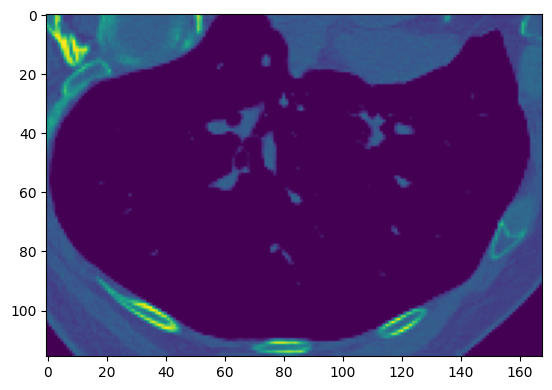

In [46]:
block.max()
plt.imshow(block[0,:,:,50])

In [38]:
arr.max()

7.754883

In [47]:
new_dir = r"C:\Users\danie\Desktop\FSE 23-34\Master's Project\DL_NTCP_Multitox\datasets\cropped_M3D_Seg_2\blocks"

new_files = os.listdir(new_dir)
len(new_files)

save_folder = "M3D_Seg"
train_data_folder = "train"
test_data_folder = "test"
test_set_size = 0.1

train_data_folder_dir = os.path.join(save_folder, train_data_folder)
test_data_folder_dir = os.path.join(save_folder, test_data_folder)

os.makedirs(train_data_folder_dir, exist_ok=True)
os.makedirs(test_data_folder_dir, exist_ok=True)

for file in new_files:
    if random.random() <= test_set_size:
        save_dir = os.path.join(test_data_folder_dir, file)
    else:
        save_dir = os.path.join(train_data_folder_dir, file)

    os.rename(os.path.join(new_dir, file), save_dir)


# Dataloader

In [176]:
import torch
from torch.utils.data import Dataset, DataLoader

# Create a custom dataset class
class M3D_Seg(Dataset):
    def __init__(self, data_folder):
        self.data_folder = data_folder
        self.data_samples = os.listdir(data_folder)
        #self.data = data

    def __len__(self):
        return len(self.data_samples)

    def __getitem__(self, index):
        # Return a single data sample
        data = np.load(os.path.join(self.data_folder, self.data_samples[index]))
        data = torch.tensor(data)[0] # tuyrn into tensor and remove the first dimension
        # Get the shape of the data tensor
        data_shape = data.shape

        # Generate random coordinates for the starting point of the cube
        start_x = random.randint(0, data_shape[0] - 96)
        start_y = random.randint(0, data_shape[1] - 96)
        start_z = random.randint(0, data_shape[2] - 96)

        # Crop the cube from the data tensor
        cropped_cube = data[start_x:start_x+96, start_y:start_y+96, start_z:start_z+96]

        return cropped_cube


# Create your dataset
dataset = M3D_Seg('cropped_M3D_Seg/train')

# Create a DataLoader
batch_size = 8
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Iterate over the dataloader
for batch in dataloader:
    # Access the batched data
    print(batch.shape)

torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 96, 96])
torch.Size([8, 96, 9

In [68]:
from models import get_model

ModuleNotFoundError: No module named 'models'